In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

# AIJACK IMPORTS
from aijack.collaborative.fedavg import FedAVGClient, FedAVGServer
from aijack.defense.dp import GeneralMomentAccountant, DPSGDManager
from aijack.defense.dp.manager.client import attach_dpsgd_to_client

# --- PARAMETRI DI TESI ---
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
batch = 32
lat_dim = 100
clients = 3

# Parametri Privacy
s = 0.5           # Sigma: Rumore aggiunto
l2 = 1.0          # Clipping: Limite alla sensibilità
t_delta = 1e-5    # Delta: Probabilità di leak ammessa

print(f"🚀 Sistema pronto su: {device}")

/Users/flaviafuscaldi/Desktop/fl_thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Sistema pronto su: mps


In [2]:
# Download e Preprocessing
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
data_dir = os.path.join(path, 'COVID-19_Radiography_Dataset')

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1), # 1 canale per radiografie
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
indices = list(range(len(full_dataset)))
np.random.shuffle(indices)

# Divisione tra i client
split = len(full_dataset) // clients
client_loaders = []
for i in range(clients):
    subset = Subset(full_dataset, indices[i*split : (i+1)*split])
    client_loaders.append(DataLoader(subset, batch_size=batch, shuffle=True))
    print(f"🏥 Ospedale {i+1}: {len(subset)} immagini caricate.")

🏥 Ospedale 1: 14110 immagini caricate.
🏥 Ospedale 2: 14110 immagini caricate.
🏥 Ospedale 3: 14110 immagini caricate.


In [3]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(lat_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False), # 1 canale
            nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False), # 1 canale
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1, 1)

global_generator = Generator().to(device)
local_discriminators = [Discriminator().to(device) for _ in range(clients)]
gen_opt = optim.Adam(global_generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [4]:
# 1. Accountant
accountant = GeneralMomentAccountant(
    noise_type="Gaussian", search="ternary", precision=0.001,
    order_max=1, order_min=72, max_iterations=1000,
    bound_type="rdp_upperbound_closedformula", backend="python"
)

# 2. DPSGDManager
privacy_manager = DPSGDManager(
    accountant, optim.Adam, l2_norm_clip=l2, dataset=full_dataset,
    lot_size=batch, batch_size=batch, iterations=100
)

# 3. Privatizzazione
dpoptimizer_cls, lot_loader, batch_loader = privacy_manager.privatize(noise_multiplier=s)
optimizer_d = dpoptimizer_cls(local_discriminators[0].parameters(), lr=0.0002)

# --- FIX ATTRIBUTEERROR: Inizializzazione gradienti ---
# Facciamo un passaggio "finto" per creare gli oggetti .grad che AIJack si aspetta
dummy_batch, _ = next(iter(client_loaders[0]))
dummy_batch = dummy_batch.to(device)
local_discriminators[0].zero_grad()
local_discriminators[0](dummy_batch).mean().backward() 
optimizer_d.zero_grad()

print("🛡️ Setup Privacy completato e gradienti inizializzati.")

🛡️ Setup Privacy completato e gradienti inizializzati.


Epoca 1 | ε: 3.3666
Epoca 2 | ε: 3.5167
Epoca 3 | ε: 3.6168
Epoca 4 | ε: 3.6947
Epoca 5 | ε: 3.7597
Epoca 6 | ε: 3.8161
Epoca 7 | ε: 3.8663
Epoca 8 | ε: 3.9120
Epoca 9 | ε: 3.9540
Epoca 10 | ε: 3.9930


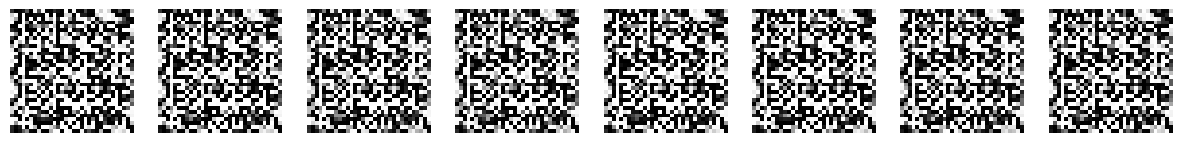

In [6]:
# --- FIX: Gradient Initialization ---
# 1. Grab a small piece of real data
dummy_x, dummy_y = next(iter(client_loaders[0])) 
dummy_x = dummy_x.to(device)

# 2. Perform a fake training step to initialize .grad attributes
optimizer_d.zero_grad()
dummy_output = local_discriminators[0](dummy_x)
loss = dummy_output.mean()
loss.backward()

# 3. Clear the fake gradients, but the .grad objects now exist!
optimizer_d.zero_grad() 
# ------------------------------------epochs = 10
for epoch in range(epochs):
    for X_lot, y_lot in lot_loader(optimizer_d):
        for X_batch, y_batch in batch_loader(TensorDataset(X_lot, y_lot)):
            optimizer_d.zero_grad()
            X_batch = X_batch.to(device)
            
            # Reali
            p_real = local_discriminators[0](X_batch)
            l_real = nn.BCELoss()(p_real, torch.ones_like(p_real) * 0.9)
            
            # Fake
            z = torch.randn(X_batch.size(0), lat_dim, 1, 1, device=device)
            f_imgs = global_generator(z)
            p_fake = local_discriminators[0](f_imgs.detach())
            l_fake = nn.BCELoss()(p_fake, torch.zeros_like(p_fake))
            
            (l_real + l_fake).backward()
            optimizer_d.step() # Il rumore viene aggiunto qui

            # Generatore
            gen_opt.zero_grad()
            l_g = nn.BCELoss()(local_discriminators[0](f_imgs), torch.ones_like(p_fake))
            l_g.backward()
            gen_opt.step()
    
    print(f"Epoca {epoch+1} | ε: {accountant.get_epsilon(delta=t_delta):.4f}")

# Visualizzazione finale
global_generator.eval()
with torch.no_grad():
    samples = global_generator(torch.randn(8, lat_dim, 1, 1, device=device)).cpu()
    plt.figure(figsize=(15, 4))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(samples[i][0].numpy() * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    plt.show()